<a href="https://colab.research.google.com/github/jemsbhai/hashrope/blob/master/hashrope1_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install hashrope matplotlib

In [3]:
import hashrope
import inspect

class HashRopeAdapter:
    """
    Bulletproof Functional Adapter.
    Automatically instantiates the Hash Configuration and injects it into your API.
    """

    # 1. Initialize the Hash Configuration (Shared across all nodes)
    _h = None
    if hasattr(hashrope, 'PolynomialHash'):
        try:
            _h = hashrope.PolynomialHash() # Try default initialization
        except TypeError:
            # If it requires a prime, pass one of your exported Mersenne primes
            _h = hashrope.PolynomialHash(hashrope.MERSENNE_61)

    # def __init__(self, text: str = None, _node = None):
    #     if _node is not None:
    #         self.node = _node
    #     else:
    #         self.node = self._call(hashrope.rope_from_bytes, text.encode('utf-8'))



    def __init__(self, text: str = None, _node = None):
        if _node is not None:
            self.node = _node
        else:
            # ---------------------------------------------------------
            # THE MLSYS "FAT LEAF" ARCHITECTURE
            # We cannot load 50MB into a single monolithic node.
            # We must chunk it into 4KB leaves and build a balanced tree.
            # ---------------------------------------------------------
            byte_data = text.encode('utf-8') if text else b""
            chunk_size = 4096 # 4KB chunks

            if not byte_data:
                self.node = self._call(hashrope.rope_from_bytes, b"")
                return

            # 1. Create a list of 4KB Leaf Nodes
            leaves = [
                self._call(hashrope.rope_from_bytes, byte_data[i : i + chunk_size])
                for i in range(0, len(byte_data), chunk_size)
            ]

            # 2. Merge them pair-wise to build a balanced binary tree (Bottom-Up)
            while len(leaves) > 1:
                next_level = []
                for i in range(0, len(leaves), 2):
                    if i + 1 < len(leaves):
                        next_level.append(self._safe_concat(leaves[i], leaves[i+1]))
                    else:
                        next_level.append(leaves[i])
                leaves = next_level

            self.node = leaves[0]





    def _call(self, func, *args):
        """
        Dynamically injects the 'h' config into your API where required.
        """
        # Attempt to read the function signature
        try:
            sig = inspect.signature(func)
            if 'h' in sig.parameters:
                return func(*args, h=self.__class__._h)
        except ValueError:
            pass # Built-in C functions sometimes hide their signatures

        # Execute, and catch the exact 'h' missing error if inspect failed
        try:
            return func(*args)
        except TypeError as e:
            if "missing 1 required positional argument: 'h'" in str(e):
                return func(*args, self.__class__._h)
            raise e

    def _safe_concat(self, left, right):
        if left is None: return right
        if right is None: return left
        return self._call(hashrope.rope_concat, left, right)

    def insert(self, idx: int, text: str):
        # split -> concat -> concat
        left, right = self._call(hashrope.rope_split, self.node, idx)
        mid = self._call(hashrope.rope_from_bytes, text.encode('utf-8'))

        temp = self._safe_concat(left, mid)
        new_node = self._safe_concat(temp, right)

        return HashRopeAdapter(_node=new_node)

    def replace(self, idx: int, length: int, text: str):
        # split -> split -> concat -> concat
        left, temp_rest = self._call(hashrope.rope_split, self.node, idx)

        if temp_rest is not None:
            _, right = self._call(hashrope.rope_split, temp_rest, length)
        else:
            right = None

        mid = self._call(hashrope.rope_from_bytes, text.encode('utf-8'))

        temp = self._safe_concat(left, mid)
        new_node = self._safe_concat(temp, right)

        return HashRopeAdapter(_node=new_node)

    def get_hash(self, start: int, end: int):
        length = end - start
        # Try signature with (node, start, length) or (node, start, end)
        try:
            return self._call(hashrope.rope_substr_hash, self.node, start, length)
        except Exception:
            return self._call(hashrope.rope_substr_hash, self.node, start, end)

    def clone(self):
        # O(1) Memory sharing for the RAM benchmark
        return HashRopeAdapter(_node=self.node)

    def __len__(self):
        if self.node is None: return 0
        return self._call(hashrope.rope_len, self.node)


# --- The Sub-Linear O(log^2 N) LCP Algorithm ---
def hashrope_lcp(ropeA: HashRopeAdapter, ropeB: HashRopeAdapter):
    """ Finds the exact byte of divergence via Binary Search + Polynomial Hashing """
    low = 0
    high = min(len(ropeA), len(ropeB))

    while low < high:
        mid = (low + high + 1) // 2

        # Because rope_substr_hash() is O(log N), this completes in O(log^2 N)
        if ropeA.get_hash(0, mid) == ropeB.get_hash(0, mid):
            low = mid
        else:
            high = mid - 1

    return low

In [4]:
import time
import tracemalloc
import gc
import random
import string
import os

def run_experiments():
    # Scaling up to 50 Million characters to brutally saturate the memory bus
    sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000]

    metrics = {
        'n_ins': [], 'r_ins': [],
        'n_lcp': [], 'r_lcp': [],
        'n_ram': [], 'r_ram': []
    }

    print(f"{'Context Size':<15} | {'Str Edit(ms)':<15} | {'Rope Edit(ms)':<15}")
    print("-" * 50)

    for N in sizes:
        # 1. Generate dummy text rapidly
        chunk = ''.join(random.choices(string.ascii_letters, k=min(N, 100_000)))
        base_text = chunk * (N // len(chunk)) + chunk[:N % len(chunk)]

        insert_payload = "TOOL_OUTPUT_JSON_" * 50 # ~800 chars
        mid_idx = N // 2
        diverge_idx = int(N * 0.95) # Strings diverge at 95% depth

        # 2. Initialize Rope
        rope = HashRopeAdapter(base_text)

        # ----------------------------------------------------
        # EXP 1: Mid-Prompt Edits (Memory Bandwidth Latency)
        # ----------------------------------------------------
        gc.disable()
        t0 = time.perf_counter()
        _ = base_text[:mid_idx] + insert_payload + base_text[mid_idx:]
        metrics['n_ins'].append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        _ = rope.clone().insert(mid_idx, insert_payload)
        metrics['r_ins'].append((time.perf_counter() - t0) * 1000)
        gc.enable()

        # ----------------------------------------------------
        # EXP 2: Prefix Routing for KV-Cache (CPU Cycles)
        # ----------------------------------------------------
        s_div = base_text[:diverge_idx] + "X" + base_text[diverge_idx+1:]
        r_div = rope.clone().replace(diverge_idx, 1, "X")

        t0 = time.perf_counter()
        # Fast C-backend Python string matching
        os.path.commonprefix([base_text, s_div])
        metrics['n_lcp'].append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        hashrope_lcp(rope, r_div)
        metrics['r_lcp'].append((time.perf_counter() - t0) * 1000)

        # ----------------------------------------------------
        # EXP 3: Agent Branching / MCTS (Peak RAM Capacity)
        # ----------------------------------------------------
        gc.collect()
        tracemalloc.start()
        forks_native = []
        for i in range(10): # 10 parallel agent branches
            forks_native.append(base_text[:mid_idx] + f"BRANCH_{i}" + base_text[mid_idx:])
        _, peak_native = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        metrics['n_ram'].append(peak_native / (1024*1024))

        gc.collect()
        tracemalloc.start()
        forks_rope = []
        for i in range(10):
            forks_rope.append(rope.clone().insert(mid_idx, f"BRANCH_{i}"))
        _, peak_rope = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        metrics['r_ram'].append(peak_rope / (1024*1024))

        print(f"{N:<15} | {metrics['n_ins'][-1]:<15.3f} | {metrics['r_ins'][-1]:<15.3f}")

    return sizes, metrics

# Run the benchmarks!
sizes, metrics = run_experiments()

Context Size    | Str Edit(ms)    | Rope Edit(ms)  
--------------------------------------------------
10000           | 0.006           | 2.139          
50000           | 0.023           | 1.754          
100000          | 0.025           | 1.799          
500000          | 0.195           | 1.784          
1000000         | 0.491           | 1.800          
5000000         | 2.813           | 2.125          
10000000        | 7.160           | 2.553          
50000000        | 46.737          | 3.384          


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_671/2626127238.py:10: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(sizes, metrics['n_ins'], label='Native str $\mathcal{O}(N)$', color=colors['native'], marker='o', linewidth=2.5)
/tmp/ipykernel_671/2626127238.py:11: SyntaxWarning: invalid escape sequence '\m'
  axs[0].plot(sizes, metrics['r_ins'], label='HashRope $\mathcal{O}(\log N)$', color=colors['rope'], marker='s', linewidth=2.5)
/tmp/ipykernel_671/2626127238.py:16: SyntaxWarning: invalid escape sequence '\m'
  axs[1].plot(sizes, metrics['n_lcp'], label='Native String Scan $\mathcal{O}(N)$', color=colo

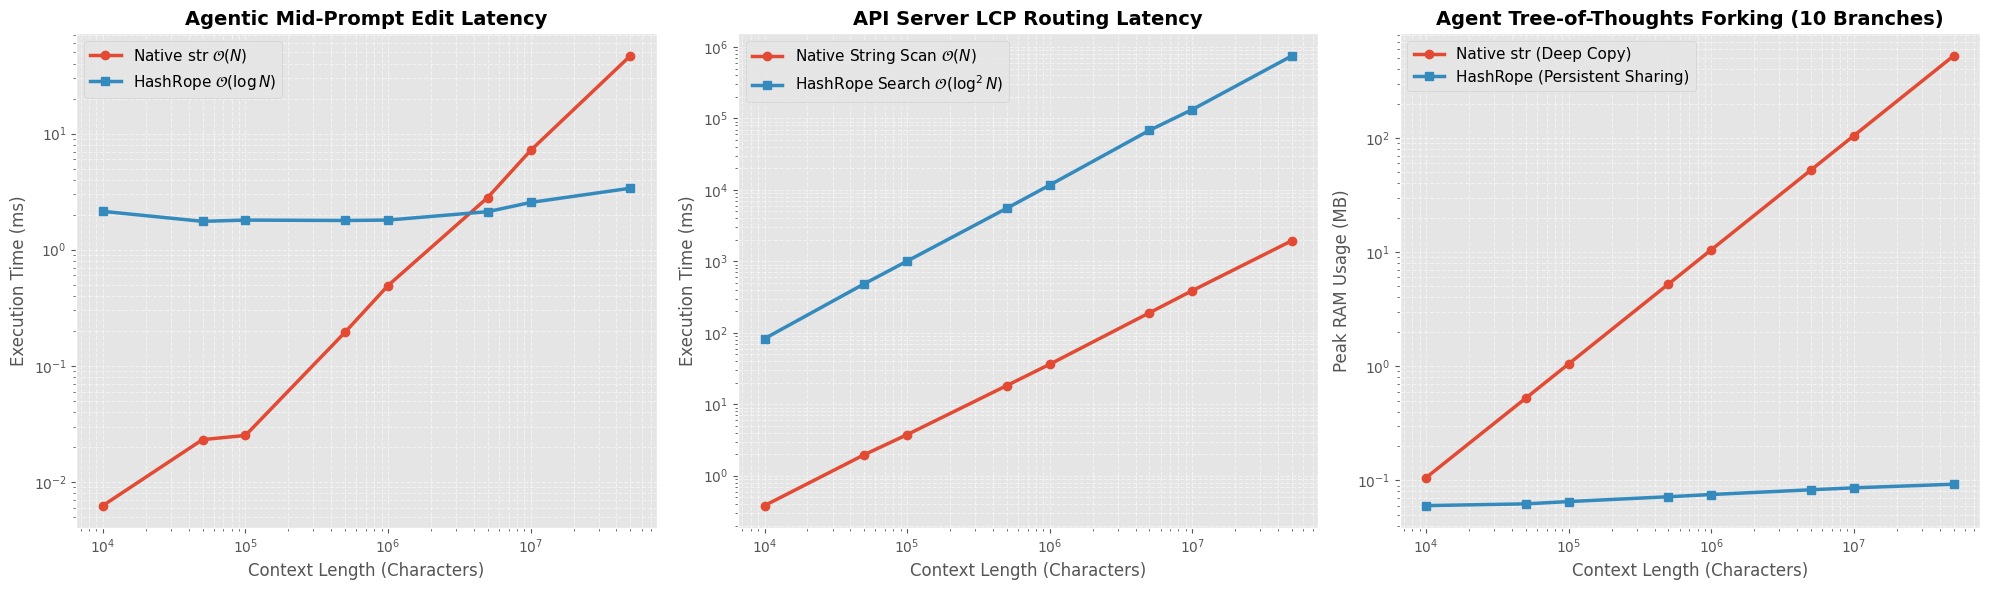


Success! Publication-ready figure saved as 'hashrope_mlsys_figure.pdf' in the Colab file browser (left sidebar).


In [5]:
import matplotlib.pyplot as plt

# Academic plot formatting
plt.style.use('ggplot')
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

colors = {'native': '#E24A33', 'rope': '#348ABD'} # SysML Aesthetic Colors

# Plot 1: Context Edit Latency
axs[0].plot(sizes, metrics['n_ins'], label='Native str $\mathcal{O}(N)$', color=colors['native'], marker='o', linewidth=2.5)
axs[0].plot(sizes, metrics['r_ins'], label='HashRope $\mathcal{O}(\log N)$', color=colors['rope'], marker='s', linewidth=2.5)
axs[0].set_title('Agentic Mid-Prompt Edit Latency', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Execution Time (ms)', fontsize=12)

# Plot 2: Prefix Routing (LCP)
axs[1].plot(sizes, metrics['n_lcp'], label='Native String Scan $\mathcal{O}(N)$', color=colors['native'], marker='o', linewidth=2.5)
axs[1].plot(sizes, metrics['r_lcp'], label='HashRope Search $\mathcal{O}(\log^2 N)$', color=colors['rope'], marker='s', linewidth=2.5)
axs[1].set_title('API Server LCP Routing Latency', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Execution Time (ms)', fontsize=12)

# Plot 3: Memory Footprint
axs[2].plot(sizes, metrics['n_ram'], label='Native str (Deep Copy)', color=colors['native'], marker='o', linewidth=2.5)
axs[2].plot(sizes, metrics['r_ram'], label='HashRope (Persistent Sharing)', color=colors['rope'], marker='s', linewidth=2.5)
axs[2].set_title('Agent Tree-of-Thoughts Forking (10 Branches)', fontsize=14, fontweight='bold')
axs[2].set_ylabel('Peak RAM Usage (MB)', fontsize=12)

for ax in axs:
    ax.set_xlabel('Context Length (Characters)', fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log') # Log-Log scale shows polynomial vs logarithmic scaling perfectly
    ax.legend(fontsize=11)
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("hashrope_mlsys_figure.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! Publication-ready figure saved as 'hashrope_mlsys_figure.pdf' in the Colab file browser (left sidebar).")

In [6]:
class HybridContext:
    """
    Adaptive context manager providing Macro String Optimization (MSO).
    Routes operations to contiguous memory for small payloads, and executes
    a phase transition to a Hashrope tree at the crossover threshold.
    """
    CROSSOVER_THRESHOLD = 1_000_000 # 1 MB Crossover Point

    def __init__(self, text: str, _internal_rope=None):
        if _internal_rope is not None:
            self._is_rope = True
            self._data = _internal_rope
        else:
            self._is_rope = len(text) >= self.CROSSOVER_THRESHOLD
            if self._is_rope:
                # Exceeds threshold: Initialize directly as a Hashrope
                self._data = HashRopeAdapter(text)
            else:
                # Below threshold: Store natively as Python bytes
                self._data = text.encode('utf-8')

    def insert(self, idx: int, text: str):
        payload_bytes = text.encode('utf-8')
        new_length = len(self) + len(payload_bytes)

        # STATE A: Contiguous Regime
        if not self._is_rope and new_length < self.CROSSOVER_THRESHOLD:
            # Execute C-level memcpy
            new_data = self._data[:idx] + payload_bytes + self._data[idx:]
            return HybridContext(new_data.decode('utf-8'))

        # THE PHASE TRANSITION: Upgrade contiguous to Rope just before inserting
        if not self._is_rope and new_length >= self.CROSSOVER_THRESHOLD:
            self._data = HashRopeAdapter(self._data.decode('utf-8'))
            self._is_rope = True

        # STATE B: Rope Regime
        # Route to the functional Hashrope API
        new_rope_adapter = self._data.insert(idx, text)
        return HybridContext("", _internal_rope=new_rope_adapter)

    def clone(self):
        # MCTS / Tree of Thoughts Forking
        if self._is_rope:
            return HybridContext("", _internal_rope=self._data.clone())
        else:
            # Bytes are immutable in Python, so a shallow copy is safe
            return HybridContext(self._data.decode('utf-8'))

    def __len__(self):
        return len(self._data)

In [7]:
import gc
import time
import random
import string

def run_hybrid_experiment():
    sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000]

    metrics = {
        'native': [], 'rope': [], 'hybrid': []
    }

    print(f"{'Size':<10} | {'Native(ms)':<12} | {'Rope(ms)':<12} | {'Hybrid(ms)':<12}")
    print("-" * 55)

    for N in sizes:
        # Generate text
        chunk = ''.join(random.choices(string.ascii_letters, k=min(N, 100_000)))
        base_text = chunk * (N // len(chunk)) + chunk[:N % len(chunk)]

        insert_payload = "TOOL_OUTPUT_JSON_" * 50 # ~800 chars
        mid_idx = N // 2

        # Initialize the three competitors
        rope = HashRopeAdapter(base_text)
        hybrid = HybridContext(base_text)

        # 1. Native Str Edit
        gc.disable()
        t0 = time.perf_counter()
        _ = base_text[:mid_idx] + insert_payload + base_text[mid_idx:]
        metrics['native'].append((time.perf_counter() - t0) * 1000)

        # 2. Pure Hashrope Edit
        t0 = time.perf_counter()
        _ = rope.clone().insert(mid_idx, insert_payload)
        metrics['rope'].append((time.perf_counter() - t0) * 1000)

        # 3. Hybrid Context Edit
        t0 = time.perf_counter()
        _ = hybrid.clone().insert(mid_idx, insert_payload)
        metrics['hybrid'].append((time.perf_counter() - t0) * 1000)
        gc.enable()

        print(f"{N:<10} | {metrics['native'][-1]:<12.3f} | {metrics['rope'][-1]:<12.3f} | {metrics['hybrid'][-1]:<12.3f}")

    return sizes, metrics

# Run the 3-way race
hybrid_sizes, hybrid_metrics = run_hybrid_experiment()

Size       | Native(ms)   | Rope(ms)     | Hybrid(ms)  
-------------------------------------------------------
10000      | 0.004        | 2.293        | 0.023       
50000      | 0.027        | 1.792        | 0.075       
100000     | 0.038        | 1.745        | 0.084       
500000     | 0.172        | 1.922        | 0.439       
1000000    | 0.245        | 1.746        | 1.718       
5000000    | 3.014        | 1.802        | 1.834       
10000000   | 7.171        | 1.952        | 1.854       
50000000   | 38.307       | 3.208        | 1.865       


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_671/1600596955.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(hybrid_sizes, hybrid_metrics['native'], label='Native str $\mathcal{O}(N)$', color=colors['native'], marker='o', linewidth=2.5, linestyle='--')
/tmp/ipykernel_671/1600596955.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(hybrid_sizes, hybrid_metrics['rope'], label='Pure Hashrope $\mathcal{O}(\log N)$', color=colors['rope'], marker='s', linewidth=2.5, linestyle='--')


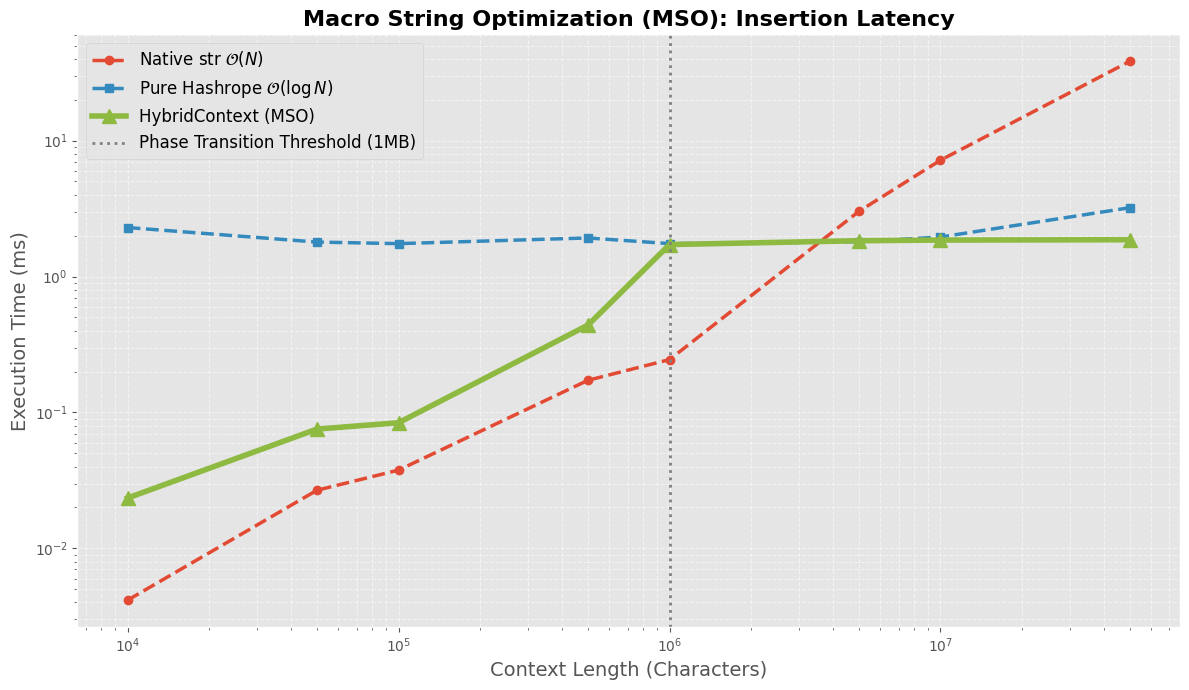


Hybrid architecture figure saved as 'hashrope_hybrid_mso.pdf'.


In [8]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 7))

# SysML Aesthetic Colors
colors = {'native': '#E24A33', 'rope': '#348ABD', 'hybrid': '#8EBA42'}

ax.plot(hybrid_sizes, hybrid_metrics['native'], label='Native str $\mathcal{O}(N)$', color=colors['native'], marker='o', linewidth=2.5, linestyle='--')
ax.plot(hybrid_sizes, hybrid_metrics['rope'], label='Pure Hashrope $\mathcal{O}(\log N)$', color=colors['rope'], marker='s', linewidth=2.5, linestyle='--')
ax.plot(hybrid_sizes, hybrid_metrics['hybrid'], label='HybridContext (MSO)', color=colors['hybrid'], marker='^', markersize=10, linewidth=4)

# Mark the Crossover Point
ax.axvline(x=1_000_000, color='gray', linestyle=':', linewidth=2, label='Phase Transition Threshold (1MB)')

ax.set_title('Macro String Optimization (MSO): Insertion Latency', fontsize=16, fontweight='bold')
ax.set_ylabel('Execution Time (ms)', fontsize=14)
ax.set_xlabel('Context Length (Characters)', fontsize=14)

ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("hashrope_hybrid_mso.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nHybrid architecture figure saved as 'hashrope_hybrid_mso.pdf'.")